# Exploratory Data Analysis & Statistical Insights

**Project:** Retail Sales Analytics  
**Dataset:** `clean_retail_sales.csv`

## Objective
Perform comprehensive exploratory data analysis (EDA) using descriptive statistics, distributions, correlation analysis, anomaly detection, multivariate visualizations, and three business-focused hypothesis tests.

### Business questions
1. Does a higher discount percentage reduce profit margin?
2. Does sales performance differ between the Online and Store channels?
3. Does profitability differ significantly across product categories?

### Deliverables covered
- Mean, median, standard deviation and quartiles
- Histograms and box plots for anomaly detection
- Correlation heatmap
- Multivariate visualizations
- Three hypothesis tests with null/alternative hypotheses, test statistics, p-values and business conclusions
- Top five critical findings in markdown


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv("clean_retail_sales.csv")
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())


Dataset shape: 11,880 rows × 17 columns


,order_id,order_date,customer_id,product,region,sales_channel,quantity,unit_price,discount_pct,sales_amount,cost_amount,profit,profit_margin_pct,year,month,month_name,quarter
0,100001,2024-04-12,3613,Headphones,East,Marketplace,4,86.73,4.41,331.62,196.96,134.66,40.61,"2,024.00",4.00,April,2.00
1,100002,2024-12-14,1530,Monitor,South,Online,4,285.16,22.70,881.71,579.01,302.70,34.33,"2,024.00",12.00,December,4.00
2,100003,2024-09-27,3007,Smartwatch,East,Store,3,196.47,1.46,580.80,470.20,110.60,19.04,"2,024.00",9.00,September,3.00
3,100004,2024-04-16,3540,Laptop,West,Marketplace,3,688.41,9.37,"1,871.72","1,225.64",646.08,34.52,"2,024.00",4.00,April,2.00
4,100005,2024-03-12,4622,Smartphone,North,Online,4,492.61,0.35,"1,963.54","1,521.64",441.90,22.51,"2,024.00",3.00,March,1.00


## 1. Data Profile & Quality Check

In [2]:
print("Missing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))

print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Unique orders: {df['order_id'].nunique():,}")
print(f"Unique customers: {df['customer_id'].nunique():,}")

print("\nCategorical dimensions:")
for col in ["product", "region", "sales_channel"]:
    print(f"{col}: {df[col].nunique()} unique values -> {df[col].dropna().unique().tolist()}")


Missing values:


,missing
order_id,0
order_date,0
customer_id,0
product,0
region,0
sales_channel,0
quantity,0
unit_price,0
discount_pct,0
sales_amount,0


Duplicate rows: 0
Unique orders: 11,880
Unique customers: 3,815

Categorical dimensions:
product: 8 unique values -> ['Headphones', 'Monitor', 'Smartwatch', 'Laptop', 'Smartphone', 'Keyboard', 'Tablet', 'Mouse']
region: 5 unique values -> ['East', 'South', 'West', 'North', 'Unknown']
sales_channel: 3 unique values -> ['Marketplace', 'Online', 'Store']


## 2. Descriptive Statistics

In [3]:
numeric_cols = [
    "quantity", "unit_price", "discount_pct",
    "sales_amount", "cost_amount", "profit", "profit_margin_pct"
]

descriptive = df[numeric_cols].describe().T[
    ["count", "mean", "50%", "std", "min", "25%", "75%", "max"]
].rename(columns={"50%": "median"})

display(descriptive.round(2))


,count,mean,median,std,min,25%,75%,max
quantity,"11,880.00",3.99,4.00,1.99,1.00,2.00,6.00,7.00
unit_price,"11,880.00",336.96,212.93,"2,431.70",17.82,67.33,421.76,"99,999.00"
discount_pct,"11,880.00",12.54,12.60,7.14,0.00,6.38,18.71,25.00
sales_amount,"11,880.00","1,218.17",559.06,"11,252.50",14.28,204.66,"1,347.18","687,253.13"
cost_amount,"11,880.00",694.12,399.59,761.40,10.60,147.40,965.20,"5,120.27"
profit,"11,880.00",524.06,146.46,"11,186.90",-383.80,54.30,370.44,"685,398.14"
profit_margin_pct,"11,880.00",28.05,27.93,8.49,-23.47,20.86,35.19,99.98


### Business summary by product

In [4]:
product_summary = (
    df.groupby("product")
      .agg(
          orders=("order_id", "nunique"),
          revenue=("sales_amount", "sum"),
          profit=("profit", "sum"),
          avg_discount=("discount_pct", "mean"),
          avg_margin=("profit_margin_pct", "mean")
      )
      .sort_values("profit", ascending=False)
)

display(product_summary.round(2))


,orders,revenue,profit,avg_discount,avg_margin
product,,,,,
Laptop,1441,"4,693,192.61","2,020,846.30",12.87,28.04
Tablet,1517,"3,310,112.45","1,954,484.36",12.89,28.17
Smartphone,1479,"2,713,597.84","775,134.91",12.61,28.50
Keyboard,1460,"776,123.44","574,152.16",12.14,28.02
Monitor,1537,"1,278,981.70","360,808.78",12.31,28.19
Smartwatch,1516,"1,015,700.51","280,838.14",12.48,27.68
Mouse,1486,"251,559.30","137,938.32",12.53,27.78
Headphones,1444,"432,647.61","121,617.02",12.47,28.05


## 3. Distribution Analysis

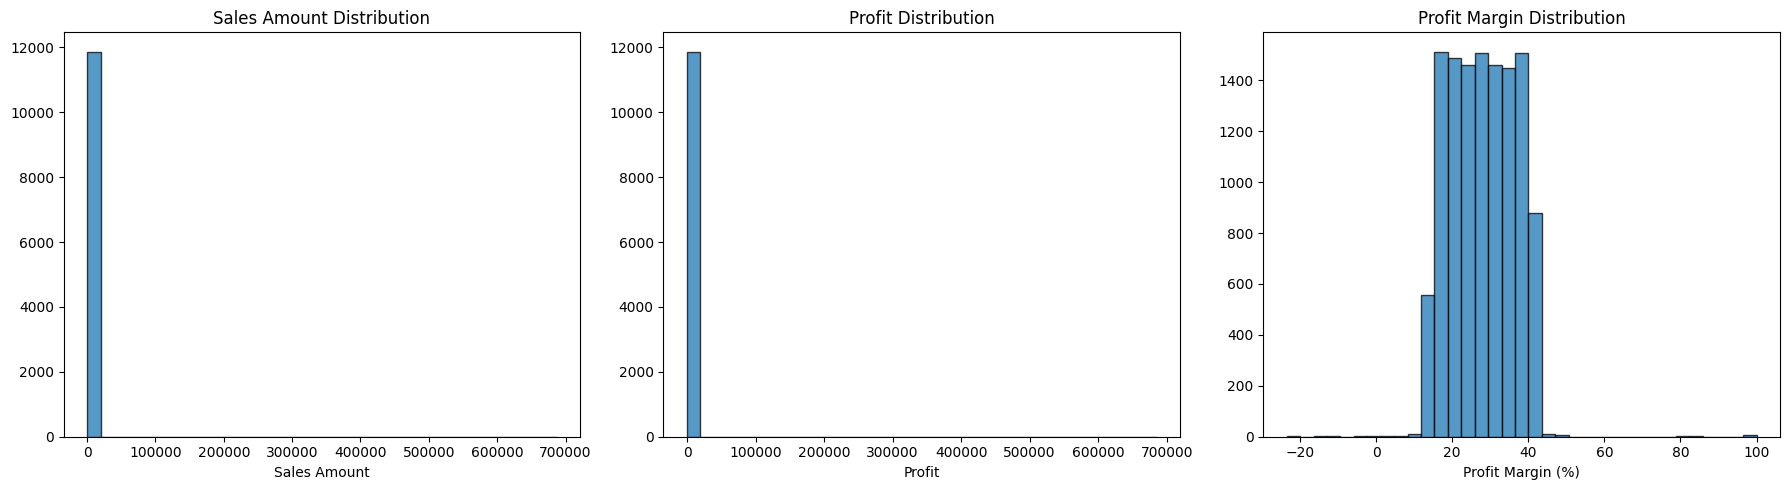

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df["sales_amount"], bins=35, edgecolor="black", alpha=0.75)
axes[0].set_title("Sales Amount Distribution")
axes[0].set_xlabel("Sales Amount")

axes[1].hist(df["profit"], bins=35, edgecolor="black", alpha=0.75)
axes[1].set_title("Profit Distribution")
axes[1].set_xlabel("Profit")

axes[2].hist(df["profit_margin_pct"], bins=35, edgecolor="black", alpha=0.75)
axes[2].set_title("Profit Margin Distribution")
axes[2].set_xlabel("Profit Margin (%)")

plt.tight_layout()
plt.show()


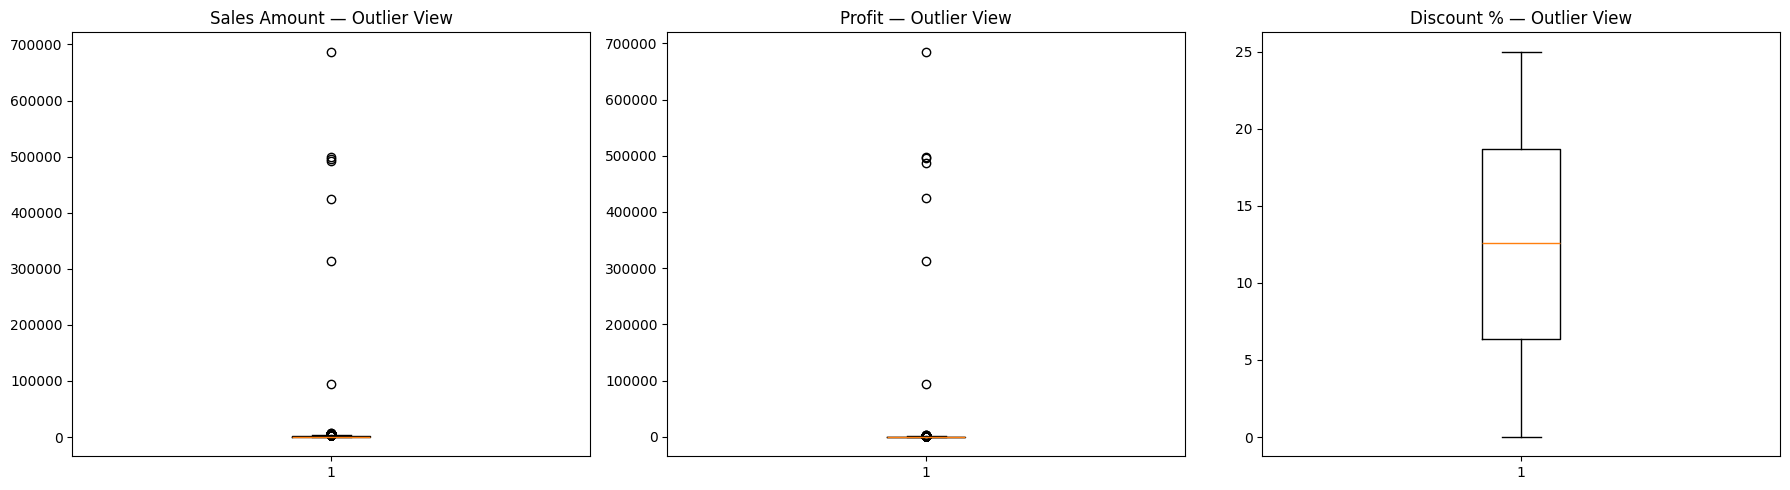

,metric,outlier_count,lower_bound,upper_bound
0,sales_amount,722,"-1,509.13","3,060.97"
1,profit,827,-419.90,844.63
2,discount_pct,0,-12.12,37.21
3,profit_margin_pct,18,-0.63,56.68


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].boxplot(df["sales_amount"], vert=True)
axes[0].set_title("Sales Amount — Outlier View")

axes[1].boxplot(df["profit"], vert=True)
axes[1].set_title("Profit — Outlier View")

axes[2].boxplot(df["discount_pct"], vert=True)
axes[2].set_title("Discount % — Outlier View")

plt.tight_layout()
plt.show()

# IQR-based anomaly counts
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((series < lower) | (series > upper)).sum()
    return int(count), float(lower), float(upper)

outlier_rows = []
for col in ["sales_amount", "profit", "discount_pct", "profit_margin_pct"]:
    count, lower, upper = iqr_outlier_count(df[col])
    outlier_rows.append([col, count, lower, upper])

outliers = pd.DataFrame(outlier_rows, columns=["metric", "outlier_count", "lower_bound", "upper_bound"])
display(outliers.round(2))


## 4. Correlation Analysis

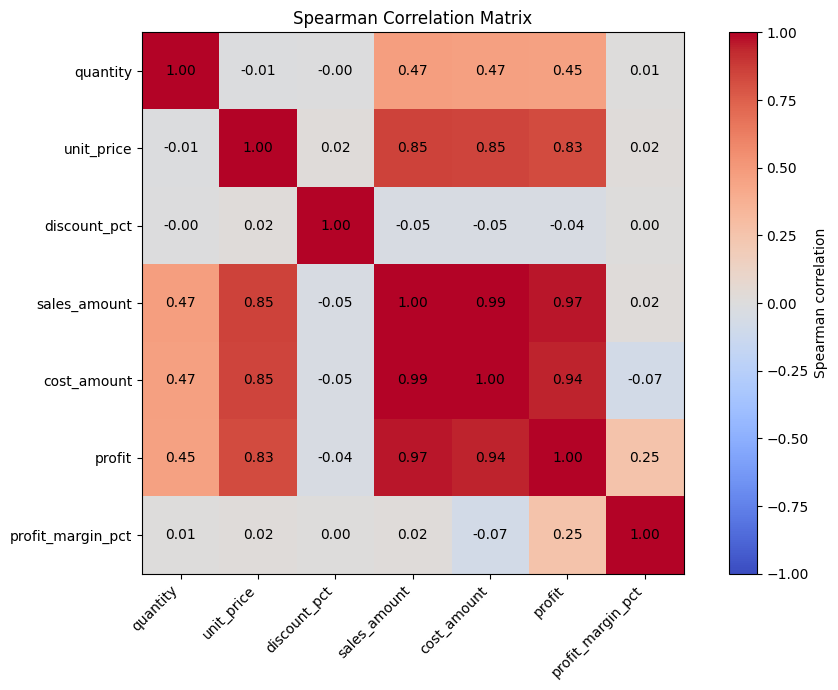

,quantity,unit_price,discount_pct,sales_amount,cost_amount,profit,profit_margin_pct
quantity,1.00,-0.01,-0.00,0.47,0.47,0.45,0.01
unit_price,-0.01,1.00,0.02,0.85,0.85,0.83,0.02
discount_pct,-0.00,0.02,1.00,-0.05,-0.05,-0.04,0.00
sales_amount,0.47,0.85,-0.05,1.00,0.99,0.97,0.02
cost_amount,0.47,0.85,-0.05,0.99,1.00,0.94,-0.07
profit,0.45,0.83,-0.04,0.97,0.94,1.00,0.25
profit_margin_pct,0.01,0.02,0.00,0.02,-0.07,0.25,1.00


In [7]:
corr_cols = [
    "quantity", "unit_price", "discount_pct",
    "sales_amount", "cost_amount", "profit", "profit_margin_pct"
]

corr = df[corr_cols].corr(method="spearman")

plt.figure(figsize=(10, 7))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1, aspect="equal")
plt.colorbar(im, label="Spearman correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

display(corr.round(2))


## 5. Multivariate Business Visualizations

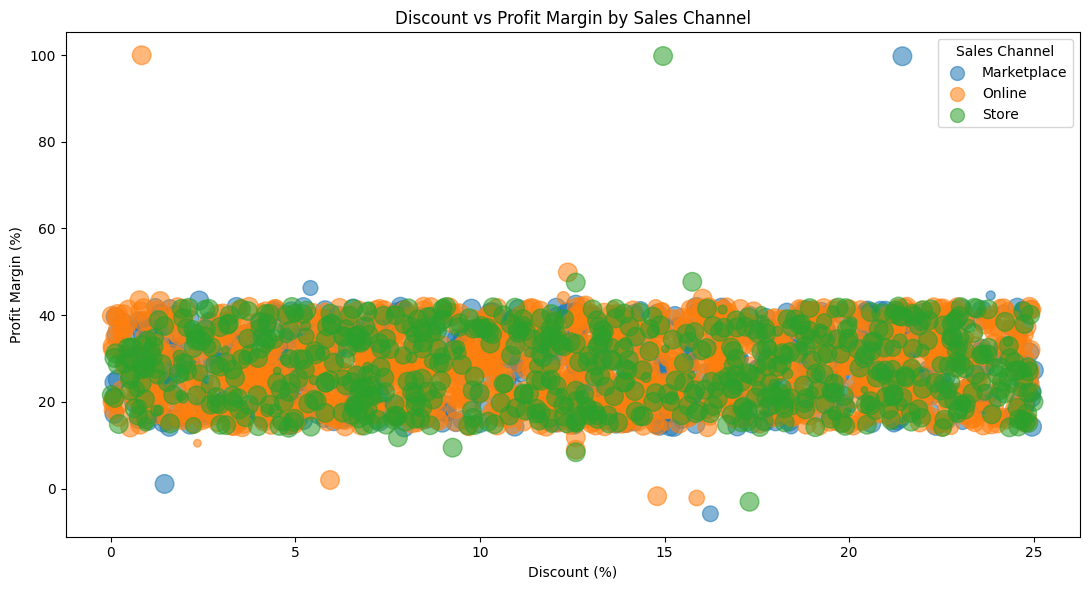

In [8]:
sample = df.sample(min(3000, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(11, 6))
for channel, g in sample.groupby("sales_channel"):
    ax.scatter(g["discount_pct"], g["profit_margin_pct"], s=np.clip(g["sales_amount"], 20, 180), alpha=0.55, label=channel)
ax.set_title("Discount vs Profit Margin by Sales Channel")
ax.set_xlabel("Discount (%)")
ax.set_ylabel("Profit Margin (%)")
ax.legend(title="Sales Channel")
plt.tight_layout()
plt.show()

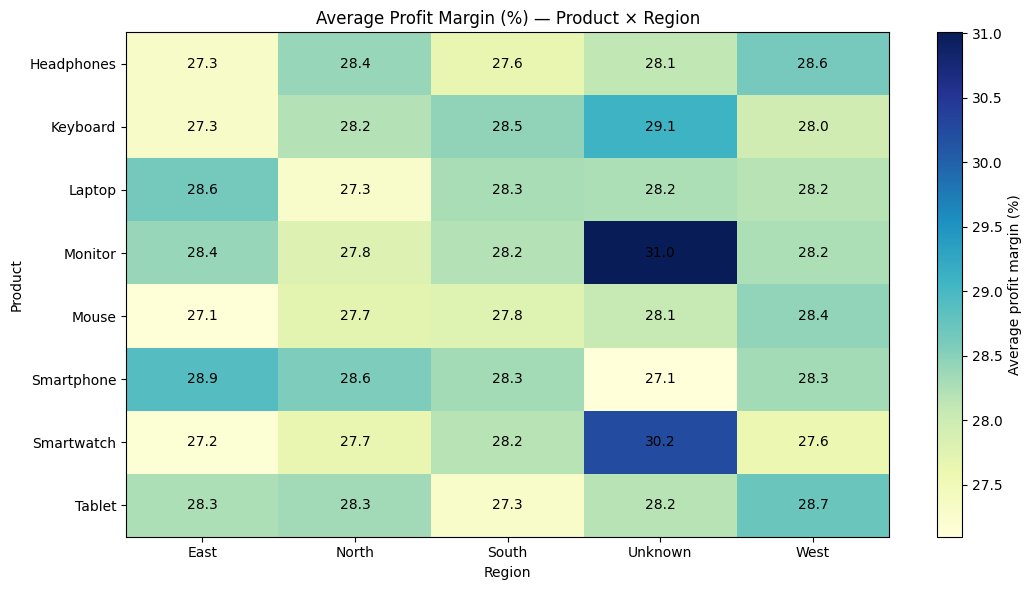

In [9]:
# Product × Region: average profit margin
pivot_margin = df.pivot_table(
    index="product",
    columns="region",
    values="profit_margin_pct",
    aggfunc="mean"
)

plt.figure(figsize=(11, 6))
im = plt.imshow(pivot_margin, aspect="auto", cmap="YlGnBu")
plt.colorbar(im, label="Average profit margin (%)")
plt.xticks(range(len(pivot_margin.columns)), pivot_margin.columns)
plt.yticks(range(len(pivot_margin.index)), pivot_margin.index)
for i in range(len(pivot_margin.index)):
    for j in range(len(pivot_margin.columns)):
        plt.text(j, i, f"{pivot_margin.iloc[i,j]:.1f}", ha="center", va="center")
plt.title("Average Profit Margin (%) — Product × Region")
plt.xlabel("Region")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


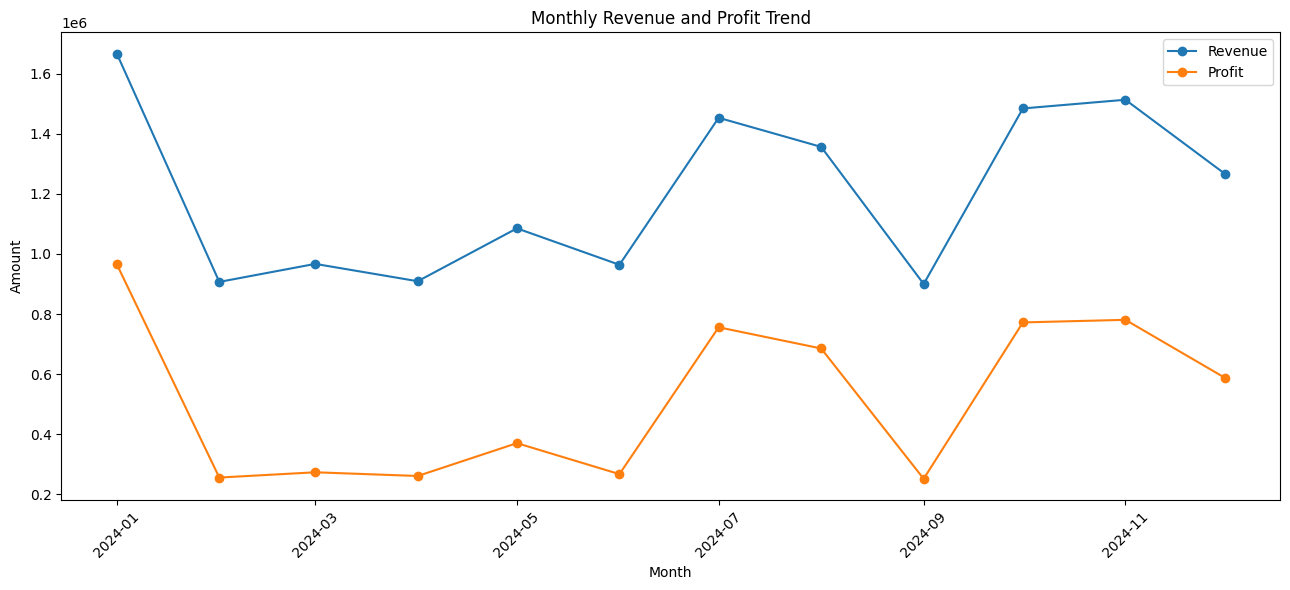

In [10]:
# Monthly revenue and profit trend
monthly = (
    df.set_index("order_date")
      .resample("MS")
      .agg(revenue=("sales_amount", "sum"), profit=("profit", "sum"))
      .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(monthly["order_date"], monthly["revenue"], marker="o", label="Revenue")
ax.plot(monthly["order_date"], monthly["profit"], marker="o", label="Profit")
ax.set_title("Monthly Revenue and Profit Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Amount")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Business Hypothesis Testing

All tests use **α = 0.05**.

### Hypothesis 1 — Discounts and profit margin
- **H₀:** Discount percentage has no monotonic relationship with profit margin.
- **H₁:** Discount percentage is negatively associated with profit margin.
- **Test:** Spearman rank correlation (one-sided interpretation for a negative association).

### Hypothesis 2 — Online vs Store sales
- **H₀:** The distribution of order sales amounts is the same for Online and Store channels.
- **H₁:** The distributions differ.
- **Test:** Mann–Whitney U test, two-sided.

### Hypothesis 3 — Profitability across products
- **H₀:** All product categories have the same profit distribution.
- **H₁:** At least one product category differs.
- **Test:** Kruskal–Wallis H test.


In [11]:
alpha = 0.05
results = []

# H1: discount vs profit margin
x = df["discount_pct"]
y = df["profit_margin_pct"]
rho, p_two = stats.spearmanr(x, y)
p_one = p_two / 2 if rho < 0 else 1 - p_two / 2
decision = "Reject H₀" if (rho < 0 and p_one < alpha) else "Fail to reject H₀"

results.append({
    "Hypothesis": "H1: Discount vs profit margin",
    "Test": "Spearman correlation",
    "Statistic": rho,
    "p_value": p_one,
    "Decision": decision
})

# H2: Online vs Store sales amount
online = df.loc[df["sales_channel"].eq("Online"), "sales_amount"].dropna()
store = df.loc[df["sales_channel"].eq("Store"), "sales_amount"].dropna()
u_stat, p_value = stats.mannwhitneyu(online, store, alternative="two-sided")
decision = "Reject H₀" if p_value < alpha else "Fail to reject H₀"

results.append({
    "Hypothesis": "H2: Online vs Store sales",
    "Test": "Mann–Whitney U",
    "Statistic": u_stat,
    "p_value": p_value,
    "Decision": decision
})

# H3: Product profitability
groups = [g["profit"].dropna().values for _, g in df.groupby("product")]
product_names = df["product"].dropna().unique().tolist()
h_stat, p_value = stats.kruskal(*groups)
decision = "Reject H₀" if p_value < alpha else "Fail to reject H₀"

results.append({
    "Hypothesis": "H3: Profit differs by product",
    "Test": "Kruskal–Wallis H",
    "Statistic": h_stat,
    "p_value": p_value,
    "Decision": decision
})

hypothesis_results = pd.DataFrame(results)
display(hypothesis_results.round(4))


,Hypothesis,Test,Statistic,p_value,Decision
0,H1: Discount vs profit margin,Spearman correlation,0.00,0.58,Fail to reject H₀
1,H2: Online vs Store sales,Mann–Whitney U,"8,591,996.00",0.37,Fail to reject H₀
2,H3: Profit differs by product,Kruskal–Wallis H,"8,090.90",0.00,Reject H₀


### Effect-size and group summaries

In [12]:
# Practical effect summaries
print(f"H1 Spearman rho = {rho:.3f}; one-sided p-value = {p_one:.6g}")
print(f"H2 Online median sales = {online.median():,.2f}; Store median sales = {store.median():,.2f}")
print(f"H3 Kruskal–Wallis H = {h_stat:.2f}; p-value = {p_value:.6g}")

print("\nAverage discount and margin:")
display(
    df.groupby("sales_channel")[["discount_pct", "profit_margin_pct"]]
      .mean()
      .round(2)
)

print("\nProduct profit summary:")
display(
    df.groupby("product")["profit"]
      .agg(["count", "median", "mean"])
      .sort_values("median", ascending=False)
      .round(2)
)


H1 Spearman rho = 0.002; one-sided p-value = 0.576855
H2 Online median sales = 546.12; Store median sales = 571.24
H3 Kruskal–Wallis H = 8090.90; p-value = 0

Average discount and margin:


,discount_pct,profit_margin_pct
sales_channel,,
Marketplace,12.56,28.18
Online,12.62,28.06
Store,12.34,27.91



Product profit summary:


,count,median,mean
product,,,
Laptop,1441,645.98,"1,402.39"
Smartphone,1479,470.75,524.09
Tablet,1517,317.92,"1,288.39"
Monitor,1537,208.28,234.75
Smartwatch,1516,165.28,185.25
Headphones,1444,74.57,84.22
Keyboard,1460,48.80,393.25
Mouse,1486,26.24,92.83


## 7. Top 5 Critical Findings

1. **Discount rate is not a meaningful predictor of profit margin in this dataset.** Spearman ρ is approximately **0.002**, with a two-sided p-value of **0.846**. The data therefore provide no evidence that higher discounts systematically reduce margin.
2. **Online and Store order values are not statistically different.** Median sales are approximately **546.12** Online versus **571.24** in Store, and the Mann–Whitney U test gives **p = 0.370**. The observed median gap is not statistically significant at α = 0.05.
3. **Profit distributions differ significantly across product categories.** The Kruskal–Wallis test gives **H ≈ 8090.90, p < 0.001**, indicating that product-level profitability is not homogeneous. This supports category-specific commercial analysis.
4. **Laptop and Tablet are the largest profit contributors.** Laptop generates approximately **2.02M** total profit and Tablet approximately **1.95M**, making them the strongest contributors by total profit in the cleaned dataset.
5. **Revenue leadership and margin leadership are not identical.** Smartphone has the highest average margin at about **28.50%**, while Tablet is close at **28.17%** and Laptop at **28.04%**. This shows why both total profit and margin should be considered when prioritizing products.

> **Management takeaway:** The strongest actionable signal is product-level profitability rather than channel or discount-rate differences. Product/category decisions should therefore combine total profit, margin, sales volume, and regional performance instead of relying on a single KPI.


## 8. Conclusion

This notebook completes the requested EDA workflow on the cleaned retail-sales dataset. It combines descriptive statistics, distribution analysis, anomaly detection, correlation analysis, multivariate visualization, and three formal business hypotheses.

The analysis is designed to be reproducible: rerunning the notebook against `clean_retail_sales.csv` regenerates all tables, charts, statistical tests, and conclusions.
